<a href="https://colab.research.google.com/github/rafliatha/fine-tuning-indobert/blob/main/TRAINING_DATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRAPEMROSESAN DAN PELATIHAN**

### 00_Unduh Library

In [14]:
!pip install transformers

### 01_Membaca Data

In [15]:
from google.colab import drive
import pandas as pd
import re

# Menyambungkan Google Drive
drive.mount('/content/drive')

# GANTI PATH SESUAI DENGAN LOKASI FILE
path_dataset = '/content/drive/MyDrive/DATASET SKRIPSI/dataset_utuh.csv'

# Membaca dataset
df = pd.read_csv(path_dataset)

print(f"Dataset termuat: {len(df)} baris")

# Menggabungkan dataframe menjadi satu kesatuan
df_all = df.copy()
print(f"Total Dataset Gabungan untuk K-Fold: {len(df_all)} baris")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset termuat: 2090 baris
Total Dataset Gabungan untuk K-Fold: 2090 baris


### 02_Text Cleaning

In [16]:
def clean_text(text):
    if type(text) != str:
        return ""

    text = text.lower() # Mengubah semua huruf menjadi kecil (case folding)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Hapus URL/Link
    text = re.sub(r'\@\w+|\#\w+', '', text) # Hapus @username dan #hashtag
    text = re.sub(r'rt[\s]+', '', text) # Hapus tanda Retweet (RT)
    text = re.sub(r'[^a-z\s]', '', text) # Hapus karakter non-alfabet (angka, emoji, tanda baca)
    text = re.sub(r'\s+', ' ', text).strip() # Hapus spasi berlebih

    return text

# Mengaplikasikan fungsi ke dataset utuh
df_all['clean_text'] = df_all['text'].apply(clean_text)

print("Contoh hasil pembersihan:")
print(df_all[['text', 'clean_text']].head())

Contoh hasil pembersihan:
                                                text  \
0  biarkan si cemas ini istirahat ya. tolong ini mah   
1                          Syg ga? Syg bgt lah pasti   
2                         Kok resah dan gelisah yo 🤔   
3  Taktahu kape harini drive parit raja ke pasir ...   
4  Percayalah, dia sangat mencintaimu..Hanya saja...   

                                          clean_text  
0   biarkan si cemas ini istirahat ya tolong ini mah  
1                           syg ga syg bgt lah pasti  
2                           kok resah dan gelisah yo  
3  taktahu kape harini drive parit raja ke pasir ...  
4  percayalah dia sangat mencintaimuhanya saja ka...  


### 03_Normalisasi Teks

In [17]:
import pandas as pd

# URL Raw dari repositori GitHub evrintobing17
# Pastikan menggunakan URL 'raw.githubusercontent.com' agar terbaca sebagai CSV murni
url_kamus = 'https://raw.githubusercontent.com/evrintobing17/NormalisasiKata/master/kamus_alay.csv'
print("[-] Menarik kamus slang 'kamus_alay.csv' langsung dari GitHub...")

# Membaca file CSV dari internet
try:
    df_kamus = pd.read_csv(url_kamus)
    print("[V] File CSV berhasil diakses!")
except Exception as e:
    print(f"[X] Gagal mengakses URL: {e}")

# Mengubah dataframe menjadi format Dictionary Python
kamus_slang = dict(zip(df_kamus['slang'], df_kamus['formal']))
print(f"[V] Berhasil memuat {len(kamus_slang)} kata gaul ke dalam memori!\n")

# Fungsi Normalisasi
def normalize_text(text):
    if type(text) != str:
        return ""
    words = text.split()
    # Cocokkan dan ganti kata. Jika tidak ada di kamus, biarkan kata aslinya.
    normalized_words = [kamus_slang.get(word, word) for word in words]
    return ' '.join(normalized_words)

# Eksekusi ke dataset latih dan uji
print("[-] Memulai proses normalisasi teks pada dataset...")
df_all['final_text'] = df_all['clean_text'].apply(normalize_text)

print("[V] Selesai! Contoh hasil normalisasi:")
print(df_all[['clean_text', 'final_text']].head())

[-] Menarik kamus slang 'kamus_alay.csv' langsung dari GitHub...
[V] File CSV berhasil diakses!
[V] Berhasil memuat 4331 kata gaul ke dalam memori!

[-] Memulai proses normalisasi teks pada dataset...
[V] Selesai! Contoh hasil normalisasi:
                                          clean_text  \
0   biarkan si cemas ini istirahat ya tolong ini mah   
1                           syg ga syg bgt lah pasti   
2                           kok resah dan gelisah yo   
3  taktahu kape harini drive parit raja ke pasir ...   
4  percayalah dia sangat mencintaimuhanya saja ka...   

                                          final_text  
0  biarkan sih cemas ini istirahat ya tolong ini mah  
1              sayang enggak sayang banget lah pasti  
2                           kok resah dan gelisah ya  
3  taktahu kape harini drive parit raja ke pasir ...  
4  percayalah dia sangat mencintaimuhanya saja ka...  


### 04_Simpan Dataset Bersih

In [18]:
# Tentukan lokasi folder di Drive dan nama file
path_simpan_all = '/content/drive/MyDrive/DATASET SKRIPSI/dataset_utuh.csv'

# Menyimpan dataframe gabungan ke format CSV
df_all.to_csv(path_simpan_all, index=False)

print("[V] Dataset utuh siap berhasil diamankan ke Google Drive!")

[V] Dataset utuh siap berhasil diamankan ke Google Drive!


### 05_Inisialisasi Tokenizer IndoBERT & IndoBERTweet

In [19]:
from transformers import AutoTokenizer

print("[-] Mengunduh dan memuat Tokenizer dari Hugging Face...")

# Tokenizer IndoBERT-Base (dari indobenchmark)
nama_model_indobert = "indobenchmark/indobert-base-p1"
tokenizer_indobert = AutoTokenizer.from_pretrained(nama_model_indobert)

# Tokenizer IndoBERTweet (dari indolem)
nama_model_indobertweet = "indolem/indobertweet-base-uncased"
tokenizer_indobertweet = AutoTokenizer.from_pretrained(nama_model_indobertweet)

print("[V] Kedua Tokenizer berhasil dimuat!\n")

# Uji coba perbandingan pemotongan kata
teks_contoh = "tugas ini bikin resah dan gelisah ya"
print(f"Teks Asli: '{teks_contoh}'\n")

print("--- Hasil Pemotongan IndoBERT-Base ---")
print("Token:", tokenizer_indobert.tokenize(teks_contoh))
print("Input IDs:", tokenizer_indobert.encode(teks_contoh))

print("\n--- Hasil Pemotongan IndoBERTweet ---")
print("Token:", tokenizer_indobertweet.tokenize(teks_contoh))
print("Input IDs:", tokenizer_indobertweet.encode(teks_contoh))

[-] Mengunduh dan memuat Tokenizer dari Hugging Face...
[V] Kedua Tokenizer berhasil dimuat!

Teks Asli: 'tugas ini bikin resah dan gelisah ya'

--- Hasil Pemotongan IndoBERT-Base ---
Token: ['tugas', 'ini', 'bikin', 'resah', 'dan', 'gelisah', 'ya']
Input IDs: [2, 1441, 92, 2999, 20132, 41, 13328, 286, 3]

--- Hasil Pemotongan IndoBERTweet ---
Token: ['tugas', 'ini', 'bikin', 'resah', 'dan', 'gelisah', 'ya']
Input IDs: [3, 3151, 1540, 9929, 18142, 1501, 16654, 3316, 4]


### 06_Tokenisasi Seluruh Dataset & Pembuatan DataLoader

In [20]:
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Konfigurasi
MAX_LEN = 128       # Panjang maksimal kata dalam 1 kalimat (128 cukup untuk Twitter)
BATCH_SIZE = 16     # Jumlah data yang diproses GPU dalam 1 waktu
FOLDS = 10          # Menerapkan 10-Fold Cross Validation

print("[-] Memulai tokenisasi untuk seluruh dataset...")

# Mengambil teks yang sudah bersih dan labelnya
texts = df_all['final_text'].tolist()
labels = df_all['label'].tolist()

# Fungsi Tokenisasi
def encode_data(tokenizer, texts_split, labels_split):
    encodings = tokenizer(
        texts_split,
        add_special_tokens=True,
        max_length=MAX_LEN,
        padding='max_length',     # Samakan panjang semua kalimat menjadi 128
        truncation=True,          # Potong kalimat jika lebih dari 128 kata
        return_attention_mask=True,
        return_tensors='pt'       # Format keluaran berupa tensor PyTorch
    )
    # Bungkus menjadi Dataset PyTorch
    return TensorDataset(encodings['input_ids'], encodings['attention_mask'], torch.tensor(labels_split, dtype=torch.long))

# Inisialisasi K-Fold
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

# Tempat menyimpan DataLoader untuk setiap fold
cv_dataloaders_indobert = []
cv_dataloaders_indobertweet = []

# Looping memecah dataset menjadi 10 lipatan
for fold, (train_idx, test_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n---> Memproses tokenisasi untuk Fold {fold + 1} / {FOLDS} ...")

    # Memisahkan data teks dan label berdasarkan indeks K-Fold
    train_texts = [texts[i] for i in train_idx]
    train_labels = [labels[i] for i in train_idx]
    test_texts = [texts[i] for i in test_idx]
    test_labels = [labels[i] for i in test_idx]

    # Eksekusi untuk IndoBERT-Base
    print("[-] Memproses data untuk IndoBERT-Base...")
    train_dataset_ib = encode_data(tokenizer_indobert, train_texts, train_labels)
    test_dataset_ib = encode_data(tokenizer_indobert, test_texts, test_labels)
    cv_dataloaders_indobert.append({
        'train': DataLoader(train_dataset_ib, sampler=RandomSampler(train_dataset_ib), batch_size=BATCH_SIZE),
        'test': DataLoader(test_dataset_ib, sampler=SequentialSampler(test_dataset_ib), batch_size=BATCH_SIZE)
        })

    # Eksekusi untuk IndoBERTweet
    print("[-] Memproses data untuk IndoBERTweet...")
    train_dataset_ibt = encode_data(tokenizer_indobertweet, train_texts, train_labels)
    test_dataset_ibt = encode_data(tokenizer_indobertweet, test_texts, test_labels)
    cv_dataloaders_indobertweet.append({
        'train': DataLoader(train_dataset_ibt, sampler=RandomSampler(train_dataset_ibt), batch_size=BATCH_SIZE),
        'test': DataLoader(test_dataset_ibt, sampler=SequentialSampler(test_dataset_ibt), batch_size=BATCH_SIZE)
        })

print(f"\n[V] Sukses! Dataset berhasil dibungkus menjadi {len(cv_dataloaders_indobert)} pasang DataLoader IndoBERT-Base dan {len(cv_dataloaders_indobertweet)} pasang DataLoader IndoBERTweet!")

[-] Memulai tokenisasi untuk seluruh dataset...

---> Memproses tokenisasi untuk Fold 1 / 10 ...
[-] Memproses data untuk IndoBERT-Base...
[-] Memproses data untuk IndoBERTweet...

---> Memproses tokenisasi untuk Fold 2 / 10 ...
[-] Memproses data untuk IndoBERT-Base...
[-] Memproses data untuk IndoBERTweet...

---> Memproses tokenisasi untuk Fold 3 / 10 ...
[-] Memproses data untuk IndoBERT-Base...
[-] Memproses data untuk IndoBERTweet...

---> Memproses tokenisasi untuk Fold 4 / 10 ...
[-] Memproses data untuk IndoBERT-Base...
[-] Memproses data untuk IndoBERTweet...

---> Memproses tokenisasi untuk Fold 5 / 10 ...
[-] Memproses data untuk IndoBERT-Base...
[-] Memproses data untuk IndoBERTweet...

---> Memproses tokenisasi untuk Fold 6 / 10 ...
[-] Memproses data untuk IndoBERT-Base...
[-] Memproses data untuk IndoBERTweet...

---> Memproses tokenisasi untuk Fold 7 / 10 ...
[-] Memproses data untuk IndoBERT-Base...
[-] Memproses data untuk IndoBERTweet...

---> Memproses tokenisasi u

### 07_Inisialisasi Model, Optimizer, dan Pengaturan GPU

In [21]:
import time
import datetime
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("[-] Menyiapkan arsitektur model dan GPU...")

# Menentukan Perangkat (Wajib menggunakan GPU untuk training)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Perangkat yang digunakan: {device.type.upper()}")

# Fungsi pembantu untuk memformat waktu (jam:menit:detik)
def format_time(elapsed):
    return str(datetime.timedelta(seconds=int(round((elapsed)))))

# JUMLAH LABEL KLASIFIKASI KESEHATAN MENTAL
# (2 untuk Depresi/Tidak Depresi, atau 3 jika ada kelas Netral)
JUMLAH_LABEL = 2

# Pengaturan Optimizer (AdamW sangat direkomendasikan untuk keluarga BERT)
# DARI SEBELUMNYA 10, DIUBAH KE 4 AGAR TIDAK OVERFITTING (MENGHAFAL KATA KUNCI)
EPOCHS = 4

# Fungsi ini dipanggil di setiap Fold agar model kembali 'kosong'
def initialize_model(nama_model):
    model = AutoModelForSequenceClassification.from_pretrained(
        nama_model,
        num_labels=JUMLAH_LABEL,
        output_attentions=False,
        output_hidden_states=False
    )
    model.to(device)
    return model

print("[V] Model, Optimizer, dan Scheduler berhasil disiapkan!")
print(f"[*] Total Epochs: {EPOCHS}")

[-] Menyiapkan arsitektur model dan GPU...
[*] Perangkat yang digunakan: CUDA
[V] Model, Optimizer, dan Scheduler berhasil disiapkan!
[*] Total Epochs: 4


### 08_Looping 10-Fold

In [22]:
import copy
import time

# Tempat menyimpan nilai metrik dari ke-10 Fold
metrics_indobert = {'acc': [], 'prec': [], 'rec': [], 'f1': []}
metrics_indobertweet = {'acc': [], 'prec': [], 'rec': [], 'f1': []}

# Variabel penampung riwayat epoch
history_indobert = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
history_indobertweet = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

# PERUBAHAN 1: Menambahkan parameter history_dict agar bisa menyimpan kurva pelatihan
def run_kfold_cv(nama_model_path, dataloaders_list, nama_model_tampil, metrics_dict, history_dict):
    print(f"\n========== Memulai 10-Fold CV: {nama_model_tampil} ==========")
    total_t0 = time.time()

    best_f1_score = 0.0
    best_model = None

    # PERUBAHAN 2: Variabel untuk menyimpan tebakan terbaik untuk Confusion Matrix
    best_predictions = []
    best_true_labels = []

    for fold_idx in range(len(dataloaders_list)):
        print(f'\n======== Fold {fold_idx + 1} / {len(dataloaders_list)} ========')
        t0_fold = time.time()

        model = initialize_model(nama_model_path)
        optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8, weight_decay=0.01)

        train_dataloader = dataloaders_list[fold_idx]['train']
        test_dataloader = dataloaders_list[fold_idx]['test']

        total_steps = len(train_dataloader) * EPOCHS
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

        # Proses Training
        for epoch_i in range(0, EPOCHS):
            model.train()
            total_train_loss = 0

            # Variabel untuk menghitung akurasi training per epoch
            train_preds_epoch, train_labels_epoch = [], []

            for step, batch in enumerate(train_dataloader):
                b_input_ids = batch[0].to(device)
                b_input_mask = batch[1].to(device)
                b_labels = batch[2].to(device)

                model.zero_grad()
                outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
                loss = outputs.loss
                total_train_loss += loss.item()

                # Mengumpulkan tebakan saat training
                logits = outputs.logits.detach().cpu().numpy()
                train_preds_epoch.extend(np.argmax(logits, axis=1).flatten())
                train_labels_epoch.extend(b_labels.to('cpu').numpy().flatten())

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            # Mengkalkulasi metrik training per epoch
            avg_train_loss = total_train_loss / len(train_dataloader)
            train_acc = accuracy_score(train_labels_epoch, train_preds_epoch)

            # PROSES EVALUASI VALIDASI PER EPOCH (Agar kurva terbentuk)
            model.eval()
            total_eval_loss = 0
            val_preds_epoch, val_labels_epoch = [], []

            for batch in test_dataloader:
                b_input_ids = batch[0].to(device)
                b_input_mask = batch[1].to(device)
                b_labels = batch[2].to(device)

                with torch.no_grad():
                    outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
                    loss = outputs.loss
                    total_eval_loss += loss.item()

                    logits = outputs.logits.detach().cpu().numpy()
                    val_preds_epoch.extend(np.argmax(logits, axis=1).flatten())
                    val_labels_epoch.extend(b_labels.to('cpu').numpy().flatten())

            avg_val_loss = total_eval_loss / len(test_dataloader)
            val_acc = accuracy_score(val_labels_epoch, val_preds_epoch)

            # PERUBAHAN 3: Menyimpan data ke dalam history_dict
            history_dict['train_loss'].append(avg_train_loss)
            history_dict['val_loss'].append(avg_val_loss)
            history_dict['train_acc'].append(train_acc)
            history_dict['val_acc'].append(val_acc)

        # Proses Evaluasi Akhir FOLD untuk mendapatkan F1-Score & Metrik Utama
        model.eval()
        predictions, true_labels = [], []
        for batch in test_dataloader:
            b_input_ids = batch[0].to(device)
            b_input_mask = batch[1].to(device)
            b_labels = batch[2].to(device)

            with torch.no_grad():
                outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

            logits = outputs.logits.detach().cpu().numpy()
            predictions.extend(np.argmax(logits, axis=1).flatten())
            true_labels.extend(b_labels.to('cpu').numpy().flatten())

        acc = accuracy_score(true_labels, predictions)
        prec = precision_score(true_labels, predictions, average='macro', zero_division=0)
        rec = recall_score(true_labels, predictions, average='macro', zero_division=0)
        f1 = f1_score(true_labels, predictions, average='macro', zero_division=0)

        metrics_dict['acc'].append(acc)
        metrics_dict['prec'].append(prec)
        metrics_dict['rec'].append(rec)
        metrics_dict['f1'].append(f1)

        if f1 > best_f1_score:
            best_f1_score = f1
            best_model = copy.deepcopy(model)
            # PERUBAHAN 4: Menyimpan tebakan dari model paling bagus
            best_predictions = copy.deepcopy(predictions)
            best_true_labels = copy.deepcopy(true_labels)
            print(f"  --> [NEW BEST MODEL] Ditemukan pada Fold {fold_idx + 1} dengan F1-Score: {f1*100:.2f}%")

    # PERUBAHAN 5: Mengembalikan best_model DAN data tebakan terbaiknya
    return best_model, best_true_labels, best_predictions

# ================= EKSEKUSI =================
# Menangkap 3 output (model, true_labels, predictions)
model_terlatih_indobert, true_ib, pred_ib = run_kfold_cv(
    nama_model_indobert, cv_dataloaders_indobert, "IndoBERT-Base", metrics_indobert, history_indobert
)

model_terlatih_indobertweet, true_ibt, pred_ibt = run_kfold_cv(
    nama_model_indobertweet, cv_dataloaders_indobertweet, "IndoBERTweet", metrics_indobertweet, history_indobertweet
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.



========== Memulai 10-Fold CV: IndoBERT-Base ==========

======== Fold 1 / 10 ========


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


  --> [NEW BEST MODEL] Ditemukan pada Fold 1 dengan F1-Score: 89.95%

======== Fold 2 / 10 ========


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



======== Fold 10 / 10 ========


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 09_Menyimpan Model

In [23]:
import os

# Siapkan direktori utama di Google Drive
base_dir = '/content/drive/MyDrive/Model_Skripsi_Klasifikasi'

# Direktori khusus untuk masing-masing model
dir_tweet = os.path.join(base_dir, 'IndoBERTweet')
dir_base = os.path.join(base_dir, 'IndoBERT_Base')

# Buat folder jika belum ada
for directory in [dir_tweet, dir_base]:
    if not os.path.exists(directory):
        os.makedirs(directory)

print("[-] Mulai proses pencadangan ke Google Drive...")

# Simpan IndoBERTweet
print(f"[-] Menyimpan IndoBERTweet ke: {dir_tweet}")
model_terlatih_indobertweet.save_pretrained(dir_tweet)
tokenizer_indobertweet.save_pretrained(dir_tweet)

# Simpan IndoBERT-Base
print(f"[-] Menyimpan IndoBERT-Base ke: {dir_base}")
model_terlatih_indobert.save_pretrained(dir_base)
tokenizer_indobert.save_pretrained(dir_base)

print("[V] Kedua model dan tokenizer berhasil diamankan secara permanen!")

[-] Mulai proses pencadangan ke Google Drive...
[-] Menyimpan IndoBERTweet ke: /content/drive/MyDrive/Model_Skripsi_Klasifikasi/IndoBERTweet


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[-] Menyimpan IndoBERT-Base ke: /content/drive/MyDrive/Model_Skripsi_Klasifikasi/IndoBERT_Base


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[V] Kedua model dan tokenizer berhasil diamankan secara permanen!


### 10_Visualisasi dan Komparasi Hasil

[-] Memproses visualisasi data komparasi...

TABEL RINGKASAN HASIL 10-FOLD CROSS VALIDATION


,Model,Akurasi (%),Presisi (%),Recall (%),F1-Score (%)
0,IndoBERT-Base,88.85,89.01,88.86,88.84
1,IndoBERTweet,89.14,89.50,89.15,89.11


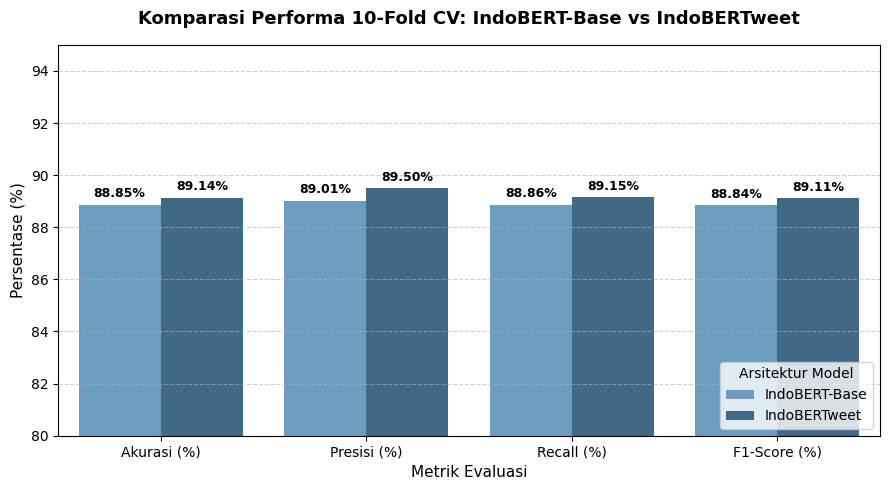

<Figure size 640x480 with 0 Axes>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[V] Grafik dan Tabel berhasil diunduh ke laptop lokal Anda!


In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

print("[-] Memproses visualisasi data komparasi...")

# Membuat DataFrame ringkasan hasil dari dictionary Sel 08
summary_data = {
    'Model': ['IndoBERT-Base', 'IndoBERTweet'],
    'Akurasi (%)': [
        np.mean(metrics_indobert['acc']) * 100,
        np.mean(metrics_indobertweet['acc']) * 100
    ],
    'Presisi (%)': [
        np.mean(metrics_indobert['prec']) * 100,
        np.mean(metrics_indobertweet['prec']) * 100
    ],
    'Recall (%)': [
        np.mean(metrics_indobert['rec']) * 100,
        np.mean(metrics_indobertweet['rec']) * 100
    ],
    'F1-Score (%)': [
        np.mean(metrics_indobert['f1']) * 100,
        np.mean(metrics_indobertweet['f1']) * 100
    ]
}

df_summary = pd.DataFrame(summary_data)

print("\n" + "="*55)
print("TABEL RINGKASAN HASIL 10-FOLD CROSS VALIDATION")
print("="*55)
# Menampilkan tabel dengan kebulatan 2 angka di belakang koma
display(df_summary.round(2))

# Persiapan data untuk Grafik Batang (Melt DataFrame)
df_melted = df_summary.melt(id_vars='Model', var_name='Metrik Evaluasi', value_name='Persentase (%)')

# Menggambar Bar Chart menggunakan Seaborn
plt.figure(figsize=(9, 5))
ax = sns.barplot(x='Metrik Evaluasi', y='Persentase (%)', hue='Model', data=df_melted, palette='Blues_d')

# Menambahkan label angka tepat di atas setiap batang grafik
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=9, fontweight='bold')

# Dekorasi Grafik
plt.title('Komparasi Performa 10-Fold CV: IndoBERT-Base vs IndoBERTweet', fontsize=13, fontweight='bold', pad=15)
plt.ylim(80, 95)  # Rentang difokuskan antara 80% - 95% agar perbedaan terlihat jelas
plt.ylabel('Persentase (%)', fontsize=11)
plt.xlabel('Metrik Evaluasi', fontsize=11)
plt.legend(loc='lower right', title='Arsitektur Model')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Tampilkan grafik
plt.show()

from google.colab import files

plt.tight_layout()

# 1. Simpan dan Download Grafik Batang (.png)
nama_file_grafik = "Grafik_Batang_Komparasi_10Fold.png"
plt.savefig(nama_file_grafik, dpi=300, bbox_inches='tight')
plt.show() # Tampilkan di layar setelah disimpan
files.download(nama_file_grafik) # Pop-up download ke laptop

# 2. Simpan dan Download Tabel Ringkasan (.csv)
nama_file_csv = "Tabel_Ringkasan_10Fold.csv"
df_summary.to_csv(nama_file_csv, index=False)
files.download(nama_file_csv) # Pop-up download ke laptop

print("[V] Grafik dan Tabel berhasil diunduh ke laptop lokal Anda!")

## 11_Visualisasi Eksplorasi Teks & Kurva Pelatihan

[-] Memulai pembuatan visualisasi dan proses unduh...

=== A. Membuat WordCloud per Kategori Label ===
 -> Menggambar & Mengunduh WordCloud: Terindikasi_Gangguan_Mental


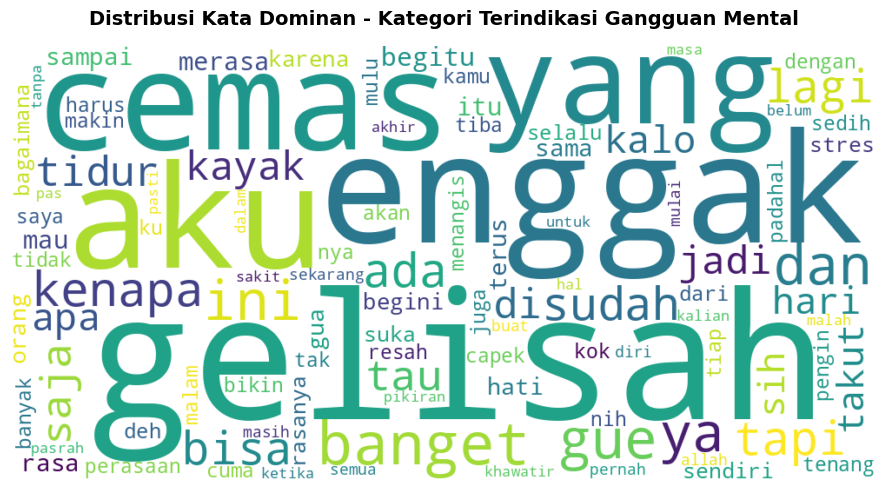

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 -> Menggambar & Mengunduh WordCloud: Stabil_atau_Netral


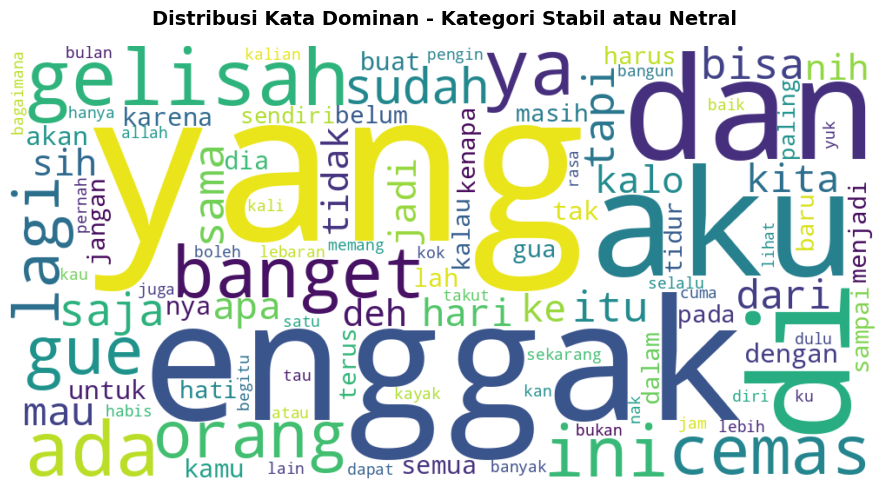

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== B. Membuat & Mengunduh Grafik Kurva Pelatihan ===


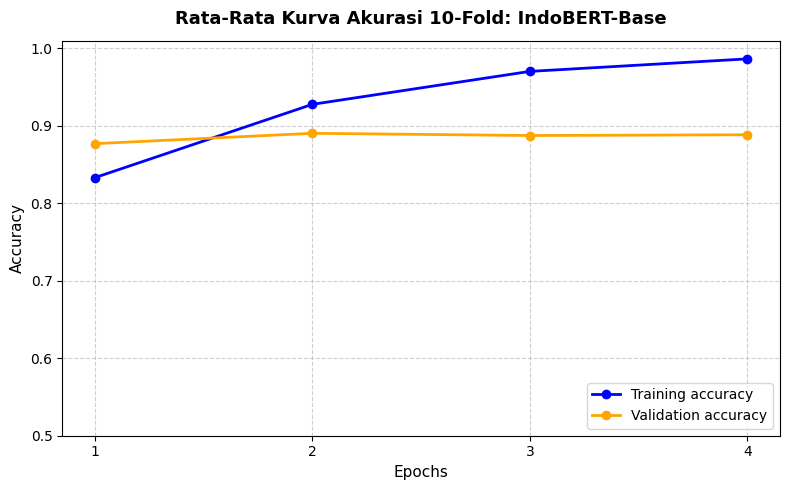

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

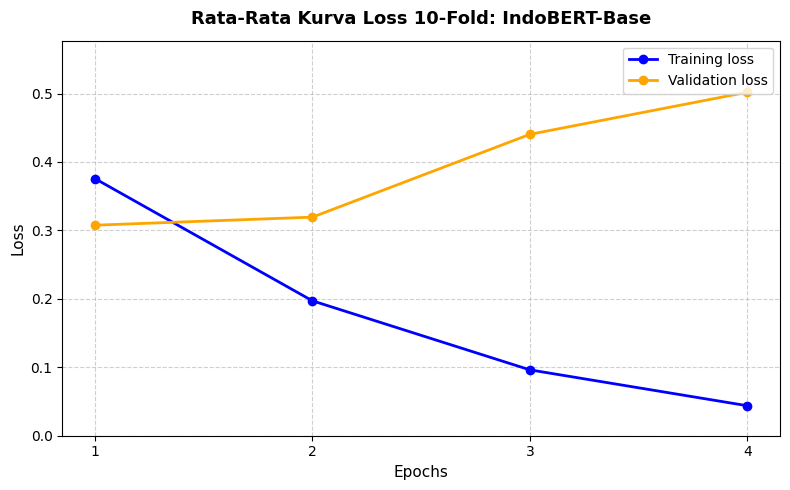

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

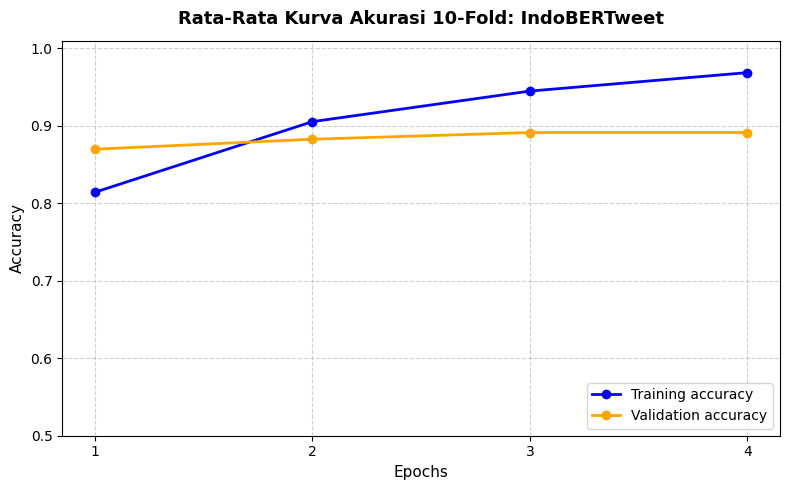

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

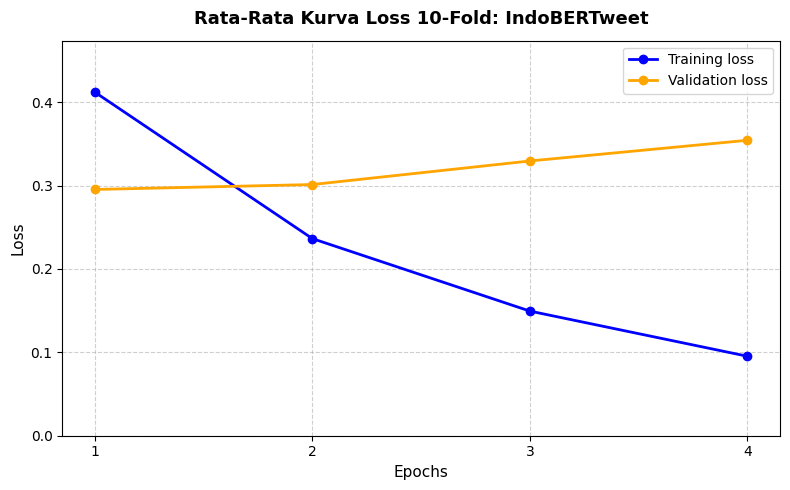

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== C. Membuat & Mengunduh Confusion Matrix ===


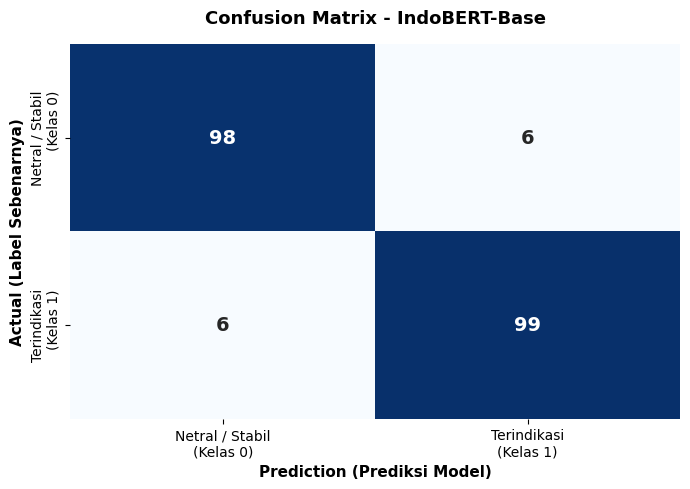

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

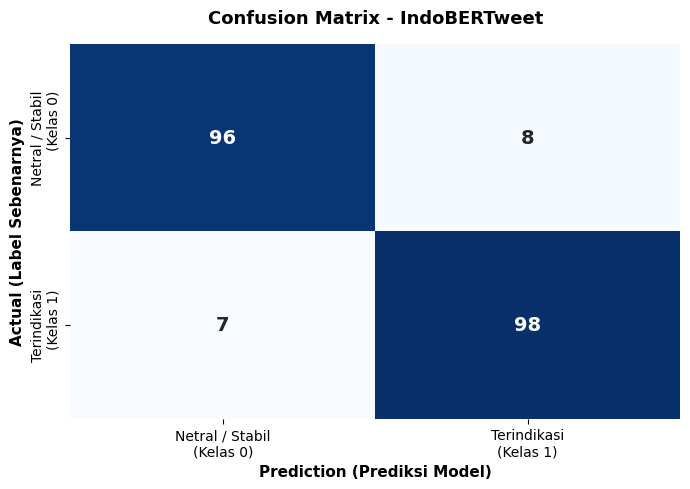

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[V] Seluruh proses generate dan download selesai!


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np
from google.colab import files # Modul untuk download langsung

print("[-] Memulai pembuatan visualisasi dan proses unduh...\n")

# ============================================
# BAGIAN A: VISUALISASI WORDCLOUD PER KATEGORI
# ============================================
print("=== A. Membuat WordCloud per Kategori Label ===")
label_map_info = {0: "Stabil_atau_Netral", 1: "Terindikasi_Gangguan_Mental"}

for label_val in df_all['label'].unique():
    teks_kumpulan = " ".join(df_all[df_all['label'] == label_val]['final_text'].astype(str).values)
    nama_label = label_map_info.get(label_val, f"Kelas_{label_val}")
    print(f" -> Menggambar & Mengunduh WordCloud: {nama_label}")

    wc = WordCloud(width=1000, height=500, background_color='white', colormap='viridis', max_words=100, collocations=False).generate(teks_kumpulan)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Distribusi Kata Dominan - Kategori {nama_label.replace('_', ' ')}", fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()

    nama_file_wc = f"WordCloud_{nama_label}.png"
    plt.savefig(nama_file_wc, dpi=300)
    plt.show()
    files.download(nama_file_wc) # Otomatis Download!

# ===========================================
# BAGIAN B: VISUALISASI KURVA AKURASI & LOSS
# ===========================================
print("\n=== B. Membuat & Mengunduh Grafik Kurva Pelatihan ===")

def plot_training_curves(history_dict, nama_model):
    # --- PERBAIKAN LOGIKA: Rata-rata metrik dari 10 Fold per Epoch ---
    # Kita ubah list (40 data) menjadi matriks 10 baris x 4 kolom, lalu ambil rata-ratanya ke bawah (axis=0)
    train_loss_avg = np.array(history_dict['train_loss']).reshape(-1, EPOCHS).mean(axis=0)
    val_loss_avg = np.array(history_dict['val_loss']).reshape(-1, EPOCHS).mean(axis=0)
    train_acc_avg = np.array(history_dict['train_acc']).reshape(-1, EPOCHS).mean(axis=0)
    val_acc_avg = np.array(history_dict['val_acc']).reshape(-1, EPOCHS).mean(axis=0)

    epochs_range = np.arange(1, EPOCHS + 1)

    # --- 1. Kurva Akurasi ---
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, train_acc_avg, label='Training accuracy', color='blue', linewidth=2, marker='o')
    plt.plot(epochs_range, val_acc_avg, label='Validation accuracy', color='orange', linewidth=2, marker='o')
    plt.title(f'Rata-Rata Kurva Akurasi 10-Fold: {nama_model}', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.xticks(epochs_range)
    plt.ylim(0.50, 1.01)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(axis='both', linestyle='--', alpha=0.6)
    plt.tight_layout()

    nama_file_acc = f"Kurva_Akurasi_{nama_model}.png"
    plt.savefig(nama_file_acc, dpi=300)
    plt.show()
    files.download(nama_file_acc) # Otomatis Download!

    # --- 2. Kurva Loss ---
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, train_loss_avg, label='Training loss', color='blue', linewidth=2, marker='o')
    plt.plot(epochs_range, val_loss_avg, label='Validation loss', color='orange', linewidth=2, marker='o')
    plt.title(f'Rata-Rata Kurva Loss 10-Fold: {nama_model}', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Loss', fontsize=11)
    plt.xticks(epochs_range)
    plt.ylim(0.0, max(max(train_loss_avg), max(val_loss_avg)) * 1.15)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(axis='both', linestyle='--', alpha=0.6)
    plt.tight_layout()

    nama_file_loss = f"Kurva_Loss_{nama_model}.png"
    plt.savefig(nama_file_loss, dpi=300)
    plt.show()
    files.download(nama_file_loss) # Otomatis Download!

try:
    if len(history_indobert['train_loss']) > 0:
        plot_training_curves(history_indobert, "IndoBERT-Base")
    if len(history_indobertweet['train_loss']) > 0:
        plot_training_curves(history_indobertweet, "IndoBERTweet")
except NameError:
    pass

# =====================================================================
# BAGIAN C: CONFUSION MATRIX 2x2
# =====================================================================
print("\n=== C. Membuat & Mengunduh Confusion Matrix ===")

def plot_cm_biner(y_true, y_pred, nama_model):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    label_grafik = ['Netral / Stabil\n(Kelas 0)', 'Terindikasi\n(Kelas 1)']

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_grafik, yticklabels=label_grafik, cbar=False, annot_kws={"size": 14, "weight": "bold"})
    plt.title(f'Confusion Matrix - {nama_model}', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Prediction (Prediksi Model)', fontsize=11, fontweight='bold')
    plt.ylabel('Actual (Label Sebenarnya)', fontsize=11, fontweight='bold')
    plt.tight_layout()

    nama_file_cm = f"Confusion_Matrix_{nama_model}.png"
    plt.savefig(nama_file_cm, dpi=300)
    plt.show()
    files.download(nama_file_cm) # Otomatis Download!

# Memanggil fungsi Confusion Matrix (Dari Sel 08)
plot_cm_biner(true_ib, pred_ib, "IndoBERT-Base")
plot_cm_biner(true_ibt, pred_ibt, "IndoBERTweet")

print("\n[V] Seluruh proses generate dan download selesai!")

## 12_Membuat File untuk Lampiran

[-] Mencetak rincian performa per iterasi (10-Fold)...
[V] File Detail_Per_Fold berhasil dicetak ke Google Drive!


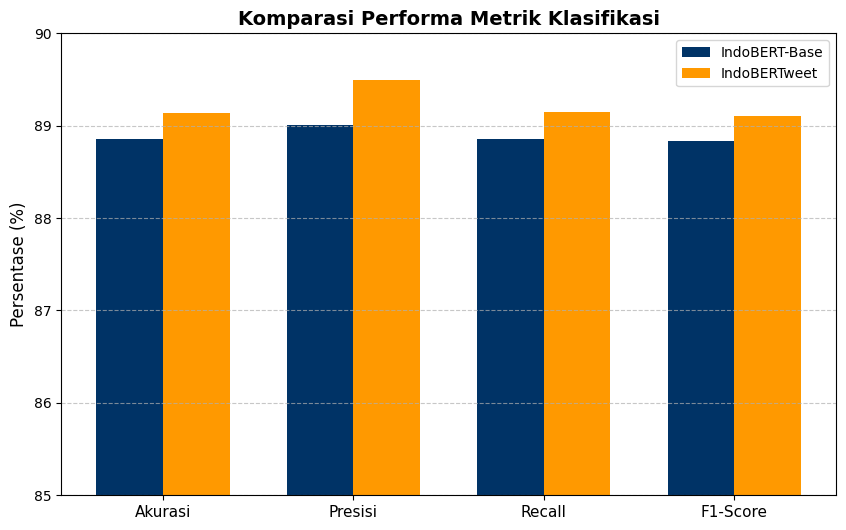

[V] File Hyperparameter_Config.txt berhasil dibuat!


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# DETAIL PER FOLD
# =====================================================================
import pandas as pd
import numpy as np

print("[-] Mencetak rincian performa per iterasi (10-Fold)...")

# 1. MENCETAK DETAIL PER FOLD INDOBERT-BASE
# Menggunakan variabel asli 'metrics_indobert' dari Sel 08
df_detail_base = pd.DataFrame({
    'Fold': range(1, len(metrics_indobert['acc']) + 1),
    'Akurasi (%)': np.array(metrics_indobert['acc']) * 100,
    'Presisi (%)': np.array(metrics_indobert['prec']) * 100,
    'Recall (%)': np.array(metrics_indobert['rec']) * 100,
    'F1-Score (%)': np.array(metrics_indobert['f1']) * 100
})
df_detail_base.to_csv('/content/drive/MyDrive/DATASET SKRIPSI/Detail_Per_Fold_IndoBERT_Base.csv', index=False)

# 2. MENCETAK DETAIL PER FOLD INDOBERTWEET
# Menggunakan variabel asli 'metrics_indobertweet' dari Sel 08
df_detail_tweet = pd.DataFrame({
    'Fold': range(1, len(metrics_indobertweet['acc']) + 1),
    'Akurasi (%)': np.array(metrics_indobertweet['acc']) * 100,
    'Presisi (%)': np.array(metrics_indobertweet['prec']) * 100,
    'Recall (%)': np.array(metrics_indobertweet['rec']) * 100,
    'F1-Score (%)': np.array(metrics_indobertweet['f1']) * 100
})
df_detail_tweet.to_csv('/content/drive/MyDrive/DATASET SKRIPSI/Detail_Per_Fold_IndoBERTweet.csv', index=False)

print("[V] File Detail_Per_Fold berhasil dicetak ke Google Drive!")

# =====================================================================
# GRAFIK BATANG KOMPARASI (BAGIAN 12)
# =====================================================================

labels = ['Akurasi', 'Presisi', 'Recall', 'F1-Score']
base_scores = df_summary.iloc[0, 1:].values
tweet_scores = df_summary.iloc[1, 1:].values

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, base_scores, width, label='IndoBERT-Base', color='#003366')
rects2 = ax.bar(x + width/2, tweet_scores, width, label='IndoBERTweet', color='#FF9900')

ax.set_ylabel('Persentase (%)', fontsize=12)
ax.set_title('Komparasi Performa Metrik Klasifikasi', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(85, 90) # Fokuskan ke rentang 85-90% agar perbedaan tipisnya terlihat

# MENYIMPAN GAMBAR
plt.savefig('/content/drive/MyDrive/DATASET SKRIPSI/Grafik_Batang_Komparasi_10Fold.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================================
# KONFIGURASI HYPERPARAMETER
# =====================================================================

# Menyimpan Hyperparameter ke file TXT
hyperparameter_text = """=========================================
KONFIGURASI HYPERPARAMETER FINE-TUNING
=========================================
Model 1         : indolem/indobert-base-uncased
Model 2         : indolem/indobertweet-base-uncased
Jumlah Epoch    : 4
Batch Size      : 16
Learning Rate   : 2e-5
Optimizer       : AdamW
Cross Validation: 10-Fold (Stratified)
Max Sequence Len: 128 Token
========================================="""

with open('/content/drive/MyDrive/DATASET SKRIPSI/Hyperparameter_Config.txt', 'w') as f:
    f.write(hyperparameter_text)

print("[V] File Hyperparameter_Config.txt berhasil dibuat!")